In [ ]:
import sys
from pathlib import Path
import pandas as pd

# Set the project root manually
project_root = Path("C:/Users/dinat/Υπολογιστής/Pfizer Masterclass/airbnb-price-prediction-app")
sys.path.append(str(project_root))

In [2]:
from backend.modeling.preprocessing import DataPreprocessor

In [3]:
from backend.constants import cols_to_drop, neighbourhood_en

# Load raw listings data
raw_df = pd.read_csv(project_root / "data" / "listings.csv")

# Configure and run preprocessing
preprocessor = DataPreprocessor()


X_train_p, X_test_p, y_train, y_test = preprocessor.fit_transform_split(raw_df, target_col="price")

print("Preprocessing completed.")
print("X_train shape:", X_train_p.shape)
print("X_test shape:", X_test_p.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train_p.head()

Preprocessing completed.
X_train shape: (7088, 72)
X_test shape: (1772, 72)
y_train shape: (7088,)
y_test shape: (1772,)


,host_total_listings_count,latitude,longitude,accommodates,bedrooms,beds,minimum_nights,maximum_nights,minimum_minimum_nights,minimum_maximum_nights,...,neighbourhood_cleansed_Rizoupoli,neighbourhood_cleansed_Sepolia,neighbourhood_cleansed_Stadio,neighbourhood_cleansed_Thiseio,neighbourhood_cleansed_Votanikos,neighbourhood_cleansed_Zappeio,room_type_Entire home/apt,room_type_Hotel room,room_type_Private room,room_type_Shared room
804,-0.559357,-0.230334,-0.461148,-1.108480,-0.629619,-0.866035,0.465942,-0.882828,0.482414,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
6508,3.038912,2.390253,0.239084,0.351911,1.146949,0.046068,1.976048,0.782335,2.000775,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
9519,-0.559357,-0.395950,-1.341686,1.812302,1.146949,0.958172,-1.044163,-0.751634,-1.035947,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
6212,-0.748740,1.277158,0.512881,-1.108480,-0.629619,-0.866035,0.465942,0.782335,0.482414,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6146,-0.748740,-0.359746,0.201878,-1.108480,-0.629619,-0.866035,-1.044163,0.782335,-1.035947,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [12]:
X_train_p[['beds', 'bedrooms', 'accommodates']].head()

,beds,bedrooms,accommodates
2982,0.881923,1.057458,2.494145
8821,0.881923,1.057458,1.765549
4157,-0.877104,-0.647868,-1.148833
1017,-0.877104,-0.647868,-0.420238
2543,0.881923,1.057458,0.308358


In [ ]:
# XGBoost hyperparameter tuning with Optuna (optimize CV MAE on price scale)
import numpy as np
import optuna
import xgboost as xg

from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold, train_test_split
from sklearn import metrics

# y_train/y_test are already log-transformed in DataPreprocessor.fit_transform_split
X_tr = X_train_p
y_tr_log = y_train.values
X_te = X_test_p
y_te_log = y_test.values

y_tr_price = np.expm1(y_tr_log)
y_te_price = np.expm1(y_te_log)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    params = {
        "objective": "reg:absoluteerror",
        "eval_metric": "mae",
        "n_estimators": trial.suggest_int("n_estimators", 800, 4500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 12),
        "subsample": trial.suggest_float("subsample", 0.55, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.55, 1.0),
        "gamma": trial.suggest_float("gamma", 1e-4, 2.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 10.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-6, 1.0, log=True),
        "n_jobs": -1,
        "random_state": 42,
        "tree_method": "hist",
    }

    fold_maes = []
    for fold_idx, (train_idx, valid_idx) in enumerate(cv.split(X_tr), start=1):
        X_fold_train = X_tr.iloc[train_idx]
        X_fold_valid = X_tr.iloc[valid_idx]
        y_fold_train_log = y_tr_log[train_idx]
        y_fold_valid_log = y_tr_log[valid_idx]
        y_fold_valid_price = np.expm1(y_fold_valid_log)

        model = xg.XGBRegressor(**params)
        model.fit(
            X_fold_train,
            y_fold_train_log,
            eval_set=[(X_fold_valid, y_fold_valid_log)],
            early_stopping_rounds=100,
            verbose=False,
        )

        pred_valid_log = model.predict(X_fold_valid, iteration_range=(0, model.best_iteration + 1))
        pred_valid_price = np.expm1(pred_valid_log)

        fold_mae = mean_absolute_error(y_fold_valid_price, pred_valid_price)
        fold_maes.append(fold_mae)

        trial.report(np.mean(fold_maes), step=fold_idx)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return float(np.mean(fold_maes))

sampler = optuna.samplers.TPESampler(seed=42)
pruner = optuna.pruners.MedianPruner(n_startup_trials=8, n_warmup_steps=2)
study = optuna.create_study(direction="minimize", sampler=sampler, pruner=pruner)
study.optimize(objective, n_trials=40, show_progress_bar=False)

best_params = study.best_trial.params
best_params.update({
    "objective": "reg:absoluteerror",
    "eval_metric": "mae",
    "n_jobs": -1,
    "random_state": 42,
    "tree_method": "hist",
})

X_final_train, X_final_valid, y_final_train_log, y_final_valid_log = train_test_split(
    X_tr, y_tr_log, test_size=0.1, random_state=42
 )

best_xgb_optuna = xg.XGBRegressor(**best_params)
best_xgb_optuna.fit(
    X_final_train,
    y_final_train_log,
    eval_set=[(X_final_valid, y_final_valid_log)],
    early_stopping_rounds=100,
    verbose=False,
 )

y_pred_log = best_xgb_optuna.predict(X_te, iteration_range=(0, best_xgb_optuna.best_iteration + 1))
y_pred_price = np.expm1(y_pred_log)

optuna_test_mae = mean_absolute_error(y_te_price, y_pred_price)
optuna_test_mape = metrics.mean_absolute_percentage_error(y_te_price, y_pred_price)
optuna_test_rmse = root_mean_squared_error(y_te_price, y_pred_price)
optuna_test_r2 = r2_score(y_te_price, y_pred_price)

print("Optuna tuning completed.")
print(f"Best CV MAE (price scale): {study.best_value:.2f}")
print("Best params:", study.best_trial.params)
print("\nOptuna-tuned XGBoost — Hold-out test (price scale):")
print(f"  MAE : {optuna_test_mae:.2f}")
print(f"  MAPE: {optuna_test_mape:.3f}")
print(f"  RMSE: {optuna_test_rmse:.2f}")
print(f"  R2  : {optuna_test_r2:.3f}")

[I 2026-03-28 17:41:28,737] A new study created in memory with name: no-name-7f454cd4-d5b4-42c7-8ee3-e8b4ad9ed1d9
[I 2026-03-28 17:42:11,326] Trial 0 finished with value: 36.035368956573954 and parameters: {'n_estimators': 2186, 'learning_rate': 0.07220721098226064, 'max_depth': 8, 'min_child_weight': 8, 'subsample': 0.6202083881990965, 'colsample_bytree': 0.6201975341512912, 'gamma': 0.00017775399007348227, 'reg_lambda': 6.697167353375242, 'reg_alpha': 0.004042872735027332}. Best is trial 0 with value: 36.035368956573954.
[I 2026-03-28 17:43:58,463] Trial 1 finished with value: 35.708877382944095 and parameters: {'n_estimators': 3420, 'learning_rate': 0.010437335666720523, 'max_depth': 10, 'min_child_weight': 10, 'subsample': 0.6455525998052243, 'colsample_bytree': 0.6318212352431953, 'gamma': 0.000614933705708711, 'reg_lambda': 1.2439367209907215, 'reg_alpha': 0.0014077923139972403}. Best is trial 1 with value: 35.708877382944095.
[I 2026-03-28 17:45:00,071] Trial 2 finished with val

Optuna tuning completed.
Best CV MAE (price scale): 35.63
Best params: {'n_estimators': 2329, 'learning_rate': 0.01631906185147605, 'max_depth': 8, 'min_child_weight': 5, 'subsample': 0.5855724347174431, 'colsample_bytree': 0.6020477295504095, 'gamma': 0.009720284122320023, 'reg_lambda': 2.113174277196991, 'reg_alpha': 0.3111919199235736}

Optuna-tuned XGBoost — Hold-out test (price scale):
  MAE : 29.70
  MAPE: 0.287
  RMSE: 221.53
  R2  : 0.419


Top 20 most important features:


,feature,importance
0,room_type_Shared room,0.079798
1,room_type_Hotel room,0.034491
2,room_type_Entire home/apt,0.034182
3,accommodates,0.030487
4,room_type_Private room,0.029475
5,bedrooms,0.027472
6,neighbourhood_cleansed_Acropolis,0.025568
7,neighbourhood_cleansed_Kerameikos,0.024486
8,neighbourhood_cleansed_Ano Patisia,0.023518
9,neighbourhood_cleansed_Commercial Triangle-Plaka,0.022101


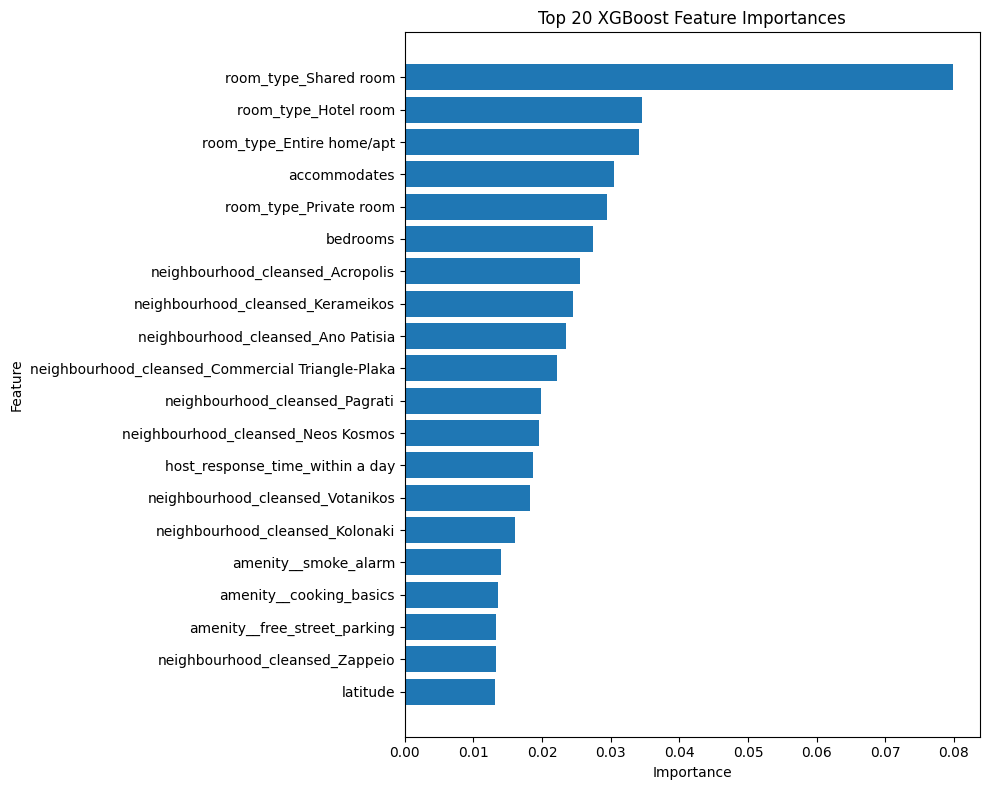

In [9]:
# Feature importance from the Optuna-tuned XGBoost model
import matplotlib.pyplot as plt
import pandas as pd

if "best_xgb_optuna" not in globals():
    raise NameError("Run the Optuna tuning cell first so best_xgb_optuna is available.")

importance_df = pd.DataFrame({
    "feature": X_train_p.columns,
    "importance": best_xgb_optuna.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("Top 20 most important features:")
display(importance_df.head(20))

top_n = 20
plot_df = importance_df.head(top_n).iloc[::-1]

plt.figure(figsize=(10, 8))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title(f"Top {top_n} XGBoost Feature Importances")
plt.tight_layout()
plt.show()

Top 20 features by mean |SHAP|:


,feature,mean_abs_shap
0,latitude,0.141334
1,accommodates,0.122341
2,availability_30,0.097422
3,bedrooms,0.064430
4,reviews_per_month,0.058257
5,calculated_host_listings_count_entire_homes,0.043869
6,amenities_count,0.038735
7,longitude,0.035825
8,amenity__smoke_alarm,0.034379
9,neighbourhood_cleansed_Commercial Triangle-Plaka,0.033532


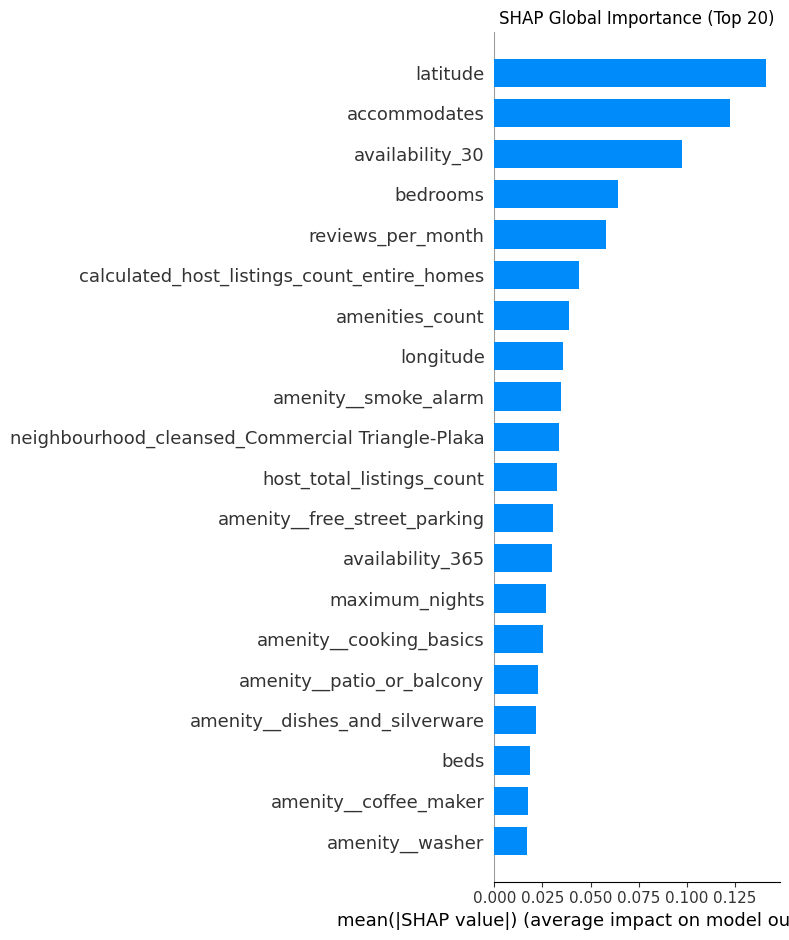

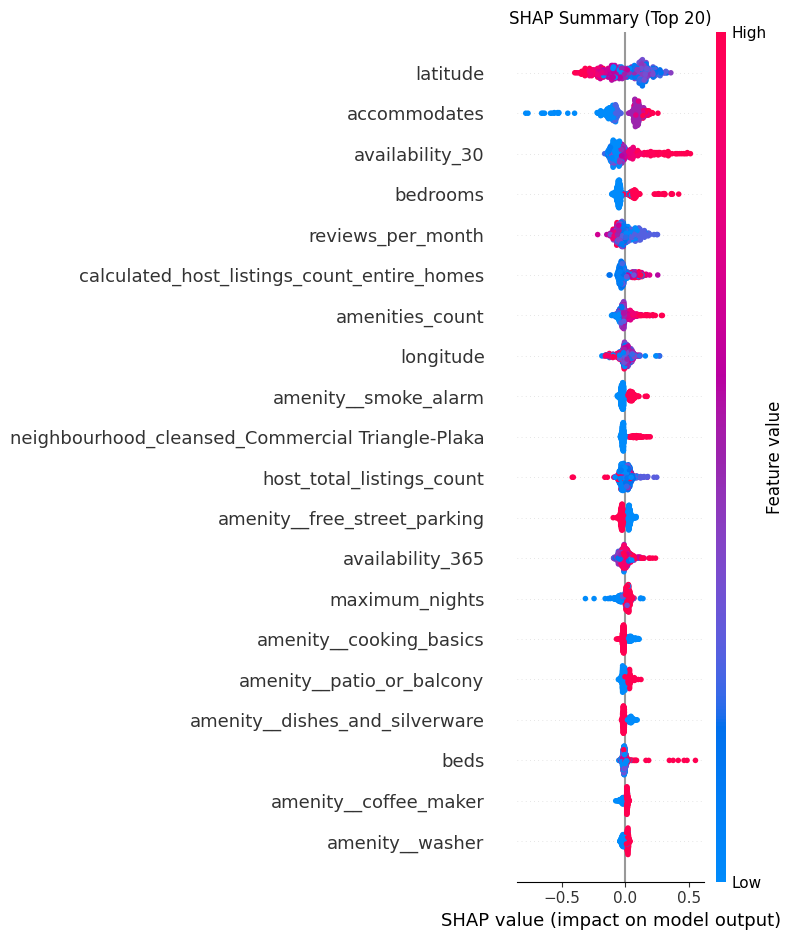

In [10]:
# SHAP analysis for the Optuna-tuned XGBoost model
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "best_xgb_optuna" not in globals():
    raise NameError("Run the Optuna tuning cell first so best_xgb_optuna is available.")

# Use a sample for faster SHAP computation
sample_n = min(500, len(X_te))
X_shap = X_te.sample(n=sample_n, random_state=42)

explainer = shap.TreeExplainer(best_xgb_optuna)
shap_values = explainer.shap_values(X_shap)

# Global importance table from mean absolute SHAP
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance_df = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": mean_abs_shap,
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

print("Top 20 features by mean |SHAP|:")
display(shap_importance_df.head(20))

# SHAP bar summary
plt.figure()
shap.summary_plot(shap_values, X_shap, plot_type="bar", max_display=20, show=False)
plt.title("SHAP Global Importance (Top 20)")
plt.tight_layout()
plt.show()

# SHAP beeswarm summary
plt.figure()
shap.summary_plot(shap_values, X_shap, max_display=20, show=False)
plt.title("SHAP Summary (Top 20)")
plt.tight_layout()
plt.show()